**Lab3-GenAI-LLM: 07-trustworthy-ai.ipynb** (BMED365) | Priority: 2 (recommended)

_Ensuring AI systems are reliable, safe, and worthy of clinical trust – AI-assisted notebook_

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/07-trustworthy-ai.ipynb)

Last updated: 2026-01-19, A. Lundervold

Use the `bmed365-2026` conda environment or Google Colab

# Trustworthy AI in Medicine

**ELMED219 / BMED365 - Lab 3: Generative AI & Large Language Models**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Define trustworthy AI** | Understand the EU's seven requirements and what makes AI worthy of clinical trust |
| **Assess robustness** | Identify vulnerabilities including distributional shift, adversarial attacks, and edge cases |
| **Quantify uncertainty** | Distinguish epistemic vs. aleatoric uncertainty and why AI should "know what it doesn't know" |
| **Design HITL workflows** | Implement human-in-the-loop systems for safe AI deployment in healthcare |
| **Validate medical AI** | Apply appropriate testing strategies including retrospective, prospective, and external validation |
| **Monitor deployed AI** | Recognize the need for continuous monitoring and how to detect performance degradation |

## Overview

| Concept | Clinical Analogy | Why It Matters |
|---------|------------------|----------------|
| **Trustworthiness** | Evidence-based medicine | Ensures AI decisions meet safety and quality standards |
| **Robustness** | Drug side effects testing | System must handle unexpected situations safely |
| **Uncertainty** | Confidence intervals in lab results | Knowing when to trust (or question) AI predictions |
| **Human oversight** | Physician final approval | Maintains clinical responsibility and catch errors |
| **Validation** | Clinical trials before drug approval | Ensures AI works in real-world conditions |

### Why This Matters for Healthcare

- 🏥 **Patient safety**: Medical AI errors can have life-or-death consequences
- ⚖️ **Regulatory requirements**: FDA, EU MDR, and other regulations demand trustworthy AI
- 🔬 **Scientific integrity**: Reproducible and validated AI supports evidence-based medicine
- 🤝 **Clinical adoption**: Physicians won't use AI they don't trust

## Contents

1. [What is Trustworthy AI?](#1-what-is-trustworthy-ai)
2. [Robustness](#2-robustness)
3. [Uncertainty Quantification](#3-uncertainty-quantification)
4. [Human-in-the-Loop](#4-human-in-the-loop)
5. [Validation and Testing](#5-validation-and-testing)
6. [Continuous Monitoring](#6-continuous-monitoring)
7. [Self-Check Questions](#7-self-check-questions)
8. [Glossary of Key Terms](#glossary-of-key-terms)
9. [Key Takeaways](#key-takeaways)
10. [Further Reading & Resources](#further-reading--resources)

---

## 1. What is Trustworthy AI?

**Trustworthy AI** is AI that is worthy of trust — meaning users can rely on the system to function as expected, be safe, and make decisions that are fair and explainable.

> 💡 **Clinical parallel**: Just as we require rigorous clinical trials before approving medications, AI systems in healthcare need comprehensive validation to earn clinical trust.

### EU's Seven Requirements for Trustworthy AI

The European Commission's High-Level Expert Group on AI established these foundational requirements:

| Requirement | Description | Medical AI Example |
|-------------|-------------|-------------------|
| **Human oversight** | Humans can override and control AI | Radiologist reviews all AI-flagged findings |
| **Robustness and safety** | System is reliable and resilient | AI fails gracefully when image quality is poor |
| **Privacy** | Data handled per regulations (GDPR) | Patient data encrypted and anonymized |
| **Transparency** | Users understand how AI works | Explainable predictions with GradCAM/SHAP |
| **Diversity and non-discrimination** | AI is fair for all groups | Equal performance across age, sex, ethnicity |
| **Societal benefit** | AI contributes positively | Improves access to diagnostic expertise |
| **Accountability** | Clear responsibility for decisions | Defined roles for developers and clinicians |

### The Trust Equation for Medical AI

```
TRUST = Accuracy + Explainability + Safety + Fairness + Regulatory Compliance
                    ─────────────────────────────────────────────────────
                                      Uncertainty + Risk
```

When uncertainty or risk is high, more evidence of trustworthiness is required.

In [7]:
# =============================================================================
# TRUSTWORTHINESS ASSESSMENT FRAMEWORK
# =============================================================================
# This framework helps evaluate whether an AI system is ready for clinical use.
# Based on EU guidelines and FDA recommendations for AI in healthcare.

def assess_trustworthiness(system_info: dict) -> dict:
    """
    Evaluate an AI system against key trustworthiness criteria.
    
    Args:
        system_info: Dictionary containing system documentation
        
    Returns:
        Dictionary of criteria with assessment questions
        
    Clinical use: Run this checklist before deploying any AI tool in a 
    clinical workflow. All questions should have satisfactory answers.
    """
    # Each criterion maps to a critical question that must be answered
    criteria = {
        "human_oversight": {
            "question": "Can humans override AI decisions?",
            "why_it_matters": "Final clinical responsibility must remain with healthcare professionals"
        },
        "robustness": {
            "question": "Is the system tested for edge cases and errors?",
            "why_it_matters": "AI must handle unusual cases safely, not just typical ones"
        },
        "explainability": {
            "question": "Can decisions be explained to users?",
            "why_it_matters": "Clinicians need to understand AI reasoning to trust and verify it"
        },
        "data_quality": {
            "question": "Are training data representative and of good quality?",
            "why_it_matters": "Biased or low-quality data leads to biased or unreliable AI"
        },
        "monitoring": {
            "question": "Is performance continuously monitored?",
            "why_it_matters": "AI performance can degrade over time (distributional shift)"
        },
        "fallback": {
            "question": "Is there a backup when AI fails?",
            "why_it_matters": "Clinical workflows must continue even when AI is unavailable"
        }
    }
    
    return criteria

# Generate the trustworthiness checklist for clinical teams
print("TRUSTWORTHINESS CHECKLIST FOR MEDICAL AI")
print("=" * 60)
print("Use this checklist before deploying AI in clinical settings\n")

for crit, info in assess_trustworthiness({}).items():
    print(f"☐ {crit.replace('_', ' ').upper()}")
    print(f"   Question: {info['question']}")
    print(f"   Why: {info['why_it_matters']}")
    print()

TRUSTWORTHINESS CHECKLIST FOR MEDICAL AI
Use this checklist before deploying AI in clinical settings

☐ HUMAN OVERSIGHT
   Question: Can humans override AI decisions?
   Why: Final clinical responsibility must remain with healthcare professionals

☐ ROBUSTNESS
   Question: Is the system tested for edge cases and errors?
   Why: AI must handle unusual cases safely, not just typical ones

☐ EXPLAINABILITY
   Question: Can decisions be explained to users?
   Why: Clinicians need to understand AI reasoning to trust and verify it

☐ DATA QUALITY
   Question: Are training data representative and of good quality?
   Why: Biased or low-quality data leads to biased or unreliable AI

☐ MONITORING
   Question: Is performance continuously monitored?
   Why: AI performance can degrade over time (distributional shift)

☐ FALLBACK
   Question: Is there a backup when AI fails?
   Why: Clinical workflows must continue even when AI is unavailable



---

## 2. Robustness

A **robust** AI system maintains reliable performance even under challenging conditions. Think of it like a medication that works consistently across different patient populations and conditions.

### What Can Go Wrong?

| Challenge | Description | Medical Example |
|-----------|-------------|-----------------|
| **Unexpected input** | Data different from training | CT scan from a new scanner model |
| **Adversarial attacks** | Deliberately manipulated input | Altered image to fool diagnosis |
| **System failures** | Network/hardware issues | PACS connection drops mid-analysis |
| **Distributional shift** | Data changes over time | Demographics of patient population changes |
| **Edge cases** | Rare but valid scenarios | Extremely rare disease presentation |

> ⚠️ **Real-world case**: A chest X-ray AI trained predominantly on adult data may fail on pediatric patients — an example of distributional shift.

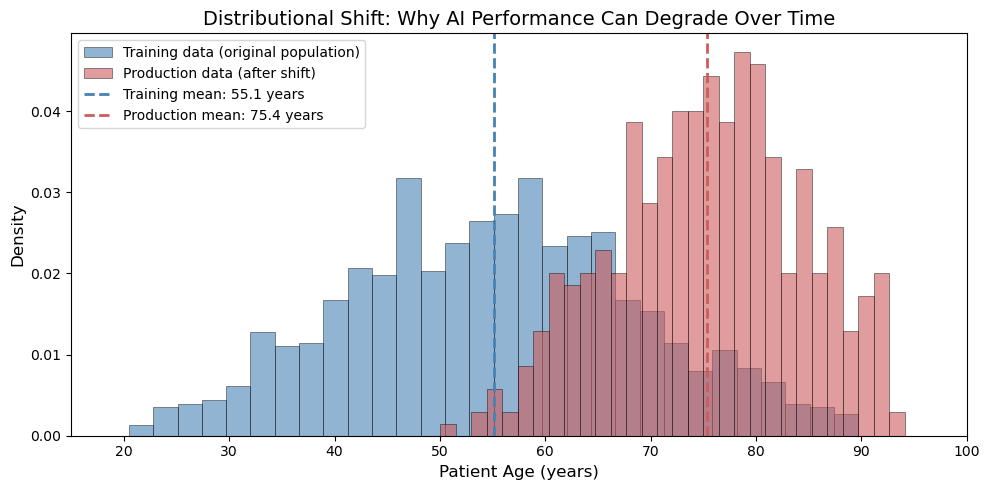


CLINICAL IMPLICATIONS OF DISTRIBUTIONAL SHIFT

📊 Statistics:
   • Training data: mean = 55.1 years, std = 13.8
   • Production data: mean = 75.4 years, std = 8.9

⚠️  Problem:
   • The AI model has learned patterns from patients aged ~55 on average
   • It's now seeing patients aged ~75 on average
   • Older patients may have different disease presentations!

💡 Solution:
   • Continuous monitoring to detect drift
   • Periodic retraining with updated data
   • Alert system when input differs significantly from training distribution


In [8]:
# =============================================================================
# DEMONSTRATION: DISTRIBUTIONAL SHIFT
# =============================================================================
# This is one of the most important concepts in deployed AI systems.
# When the data "in the wild" differs from training data, performance drops.

import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def demonstrate_distributional_shift():
    """
    Simulate how patient demographics can shift between training and deployment.
    
    Scenario: 
    - Training data: General hospital population (wide age range)
    - Production data: New geriatric ward opens (older patients)
    
    Returns:
        Tuple of (training_ages, production_ages) arrays
    """
    # Training data: Typical hospital population
    # Mean age ~55, standard deviation 15 years
    training_age = np.random.normal(55, 15, 1000)
    training_age = training_age[(training_age > 20) & (training_age < 90)]
    
    # Production data: After geriatric ward opens
    # Mean age ~75, narrower distribution (specialized unit)
    production_age = np.random.normal(75, 10, 500)
    production_age = production_age[(production_age > 50) & (production_age < 95)]
    
    return training_age, production_age

# Generate the data
training, production = demonstrate_distributional_shift()

# Visualization: Compare distributions
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(training, bins=30, alpha=0.6, label='Training data (original population)', 
        color='steelblue', density=True, edgecolor='black', linewidth=0.5)
ax.hist(production, bins=30, alpha=0.6, label='Production data (after shift)', 
        color='indianred', density=True, edgecolor='black', linewidth=0.5)

# Add visual markers for means
ax.axvline(training.mean(), color='steelblue', linestyle='--', linewidth=2, 
           label=f'Training mean: {training.mean():.1f} years')
ax.axvline(production.mean(), color='indianred', linestyle='--', linewidth=2,
           label=f'Production mean: {production.mean():.1f} years')

ax.set_xlabel('Patient Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distributional Shift: Why AI Performance Can Degrade Over Time', fontsize=14)
ax.legend(loc='upper left')
ax.set_xlim(15, 100)
plt.tight_layout()
plt.show()

# Clinical implications
print("\n" + "=" * 60)
print("CLINICAL IMPLICATIONS OF DISTRIBUTIONAL SHIFT")
print("=" * 60)
print(f"\n📊 Statistics:")
print(f"   • Training data: mean = {training.mean():.1f} years, std = {training.std():.1f}")
print(f"   • Production data: mean = {production.mean():.1f} years, std = {production.std():.1f}")
print(f"\n⚠️  Problem:")
print(f"   • The AI model has learned patterns from patients aged ~55 on average")
print(f"   • It's now seeing patients aged ~75 on average")
print(f"   • Older patients may have different disease presentations!")
print(f"\n💡 Solution:")
print(f"   • Continuous monitoring to detect drift")
print(f"   • Periodic retraining with updated data")
print(f"   • Alert system when input differs significantly from training distribution")

---

## 3. Uncertainty Quantification

A trustworthy AI should be able to say **"I am uncertain"** when it is. This is critical in medicine where overconfident wrong predictions can harm patients.

> 💡 **Clinical parallel**: Lab tests report confidence intervals (e.g., "Hemoglobin: 12.5 ± 0.3 g/dL"). AI predictions should do the same.

### Types of Uncertainty

| Type | Description | Medical Example | Can be reduced with |
|------|-------------|-----------------|---------------------|
| **Epistemic** | Model uncertainty (lack of knowledge) | Rare disease with few training examples | More data, better models |
| **Aleatoric** | Inherent noise/variability in data | Image quality variation between scanners | **Not reducible** |

### Why Uncertainty Matters

```
High confidence + Correct    → Great! Trust the AI
High confidence + Wrong      → Dangerous! No warning before harm
Low confidence  + Uncertain  → Safe! Triggers human review
```

**Key insight**: It's better for AI to say "I don't know" than to be confidently wrong.

In [9]:
# =============================================================================
# DEMONSTRATION: UNCERTAINTY-AWARE PREDICTIONS
# =============================================================================
# Modern AI systems can (and should) provide uncertainty estimates.
# This allows clinical workflows to route uncertain cases for human review.

from dataclasses import dataclass
from typing import List

@dataclass
class ClinicalPrediction:
    """
    Represents an AI prediction with uncertainty quantification.
    
    Attributes:
        description: Clinical case description
        prediction: Probability estimate (0-1)
        uncertainty: Standard deviation of prediction
        uncertainty_type: 'epistemic' (lack of data) or 'aleatoric' (inherent noise)
    """
    description: str
    prediction: float
    uncertainty: float
    uncertainty_type: str = "epistemic"

def simulate_prediction_with_uncertainty() -> List[ClinicalPrediction]:
    """
    Simulate AI predictions with uncertainty for different clinical scenarios.
    
    Returns:
        List of ClinicalPrediction objects demonstrating varying uncertainty levels
    """
    cases = [
        ClinicalPrediction(
            description="Typical pneumonia presentation, common in training data",
            prediction=0.85, 
            uncertainty=0.05,
            uncertainty_type="aleatoric"  # Small inherent variation
        ),
        ClinicalPrediction(
            description="Atypical presentation, few similar cases seen",
            prediction=0.65, 
            uncertainty=0.25,
            uncertainty_type="epistemic"  # Lack of training data
        ),
        ClinicalPrediction(
            description="Very rare autoimmune condition",
            prediction=0.55, 
            uncertainty=0.40,
            uncertainty_type="epistemic"  # Model doesn't know this well
        )
    ]
    return cases

def evaluate_prediction_safety(prediction: float, uncertainty: float, 
                                threshold: float = 0.20) -> str:
    """
    Determine if a prediction is safe for automated use or needs human review.
    
    Args:
        prediction: Model's probability estimate
        uncertainty: Standard deviation of prediction
        threshold: Maximum acceptable uncertainty for automation
        
    Returns:
        Recommendation string for clinical workflow
    """
    if uncertainty > threshold:
        return "HUMAN_REVIEW_REQUIRED"
    elif prediction > 0.80:
        return "HIGH_CONFIDENCE_POSITIVE"
    elif prediction < 0.20:
        return "HIGH_CONFIDENCE_NEGATIVE"
    else:
        return "HUMAN_REVIEW_RECOMMENDED"

# Generate and display predictions
cases = simulate_prediction_with_uncertainty()

print("UNCERTAINTY-AWARE CLINICAL AI PREDICTIONS")
print("=" * 70)
print("(Showing how AI should communicate confidence to clinicians)\n")

for i, case in enumerate(cases, 1):
    pred = case.prediction
    unc = case.uncertainty
    ci_low = max(0, pred - 1.96 * unc)  # 95% confidence interval
    ci_high = min(1, pred + 1.96 * unc)
    
    action = evaluate_prediction_safety(pred, unc)
    
    print(f"━━━ Case {i} ━━━")
    print(f"📋 Scenario: {case.description}")
    print(f"🎯 Prediction: {pred:.0%} (probability of condition)")
    print(f"📊 Uncertainty: ±{unc:.0%} ({case.uncertainty_type})")
    print(f"📈 95% CI: [{ci_low:.0%}, {ci_high:.0%}]")
    
    if action == "HUMAN_REVIEW_REQUIRED":
        print(f"⚠️  ACTION: {action} - uncertainty too high for automation")
    elif action == "HUMAN_REVIEW_RECOMMENDED":
        print(f"⚡ ACTION: {action} - borderline prediction")
    else:
        print(f"✅ ACTION: {action}")
    print()

UNCERTAINTY-AWARE CLINICAL AI PREDICTIONS
(Showing how AI should communicate confidence to clinicians)

━━━ Case 1 ━━━
📋 Scenario: Typical pneumonia presentation, common in training data
🎯 Prediction: 85% (probability of condition)
📊 Uncertainty: ±5% (aleatoric)
📈 95% CI: [75%, 95%]
✅ ACTION: HIGH_CONFIDENCE_POSITIVE

━━━ Case 2 ━━━
📋 Scenario: Atypical presentation, few similar cases seen
🎯 Prediction: 65% (probability of condition)
📊 Uncertainty: ±25% (epistemic)
📈 95% CI: [16%, 100%]
⚠️  ACTION: HUMAN_REVIEW_REQUIRED - uncertainty too high for automation

━━━ Case 3 ━━━
📋 Scenario: Very rare autoimmune condition
🎯 Prediction: 55% (probability of condition)
📊 Uncertainty: ±40% (epistemic)
📈 95% CI: [0%, 100%]
⚠️  ACTION: HUMAN_REVIEW_REQUIRED - uncertainty too high for automation



---

## 4. Human-in-the-Loop (HITL)

**Human-in-the-loop** (HITL) means humans are involved in the AI decision-making process. For medical AI, this ensures clinical accountability and catches AI errors.

> 💡 **Regulatory note**: The EU AI Act and FDA guidance require human oversight for high-risk AI applications like healthcare.

### Three Levels of Human Involvement

| Level | Description | Control | Efficiency | Medical Use Case |
|-------|-------------|---------|------------|------------------|
| **Human-IN-the-loop** | Human approves EVERY decision | 🔴 Very High | 🟢 Low | Critical diagnoses (cancer) |
| **Human-ON-the-loop** | Human monitors, can intervene | 🟡 High | 🟡 Medium | Radiology triage systems |
| **Human-OUT-of-the-loop** | Full automation | 🟢 Low | 🔴 High | ⚠️ NOT recommended for diagnosis |

### Visual Representation

```
CONTROL ◄─────────────────────────────────────────────────────────► EFFICIENCY

    HUMAN-IN-THE-LOOP          HUMAN-ON-THE-LOOP          HUMAN-OUT-OF-THE-LOOP
           │                          │                            │
    [Physician reviews           [AI triages,                [Fully automated]
     every AI output]         human spot-checks]                   
           │                          │                            │
    Example: AI-assisted       Example: Alert system        Example: NOT for 
    pathology diagnosis        for critical findings        medical diagnosis!
```

### When to Use Each Level

- **High-risk decisions** (diagnosis, treatment): Always HITL or HOTL
- **Low-risk tasks** (scheduling, reminders): May use HOTL or automation
- **Never fully automate** critical medical decisions without physician review

In [10]:
# =============================================================================
# HUMAN-IN-THE-LOOP WORKFLOW IMPLEMENTATION
# =============================================================================
# This demonstrates how a clinical AI system can route decisions based on
# confidence levels, ensuring appropriate human oversight.

from enum import Enum
from typing import Tuple

class WorkflowAction(Enum):
    """Possible actions in a HITL clinical workflow."""
    AUTO_WITH_CONFIRMATION = "Present recommendation, await physician confirmation"
    MANUAL_REVIEW = "Require independent physician assessment"
    URGENT_ESCALATION = "Immediate senior physician review"
    DOCUMENTATION_ONLY = "Document AI suggestion, no action required"

def hitl_clinical_workflow(
    ai_prediction: dict, 
    confidence_threshold: float = 0.80,
    urgency_threshold: float = 0.95
) -> Tuple[WorkflowAction, str]:
    """
    Route clinical AI predictions through appropriate human oversight.
    
    This function implements a tiered decision-support system:
    - High confidence: Present to physician for confirmation
    - Low confidence: Require independent assessment
    - Very high confidence + critical: Urgent escalation
    
    Args:
        ai_prediction: Dict with 'prediction' (str) and 'confidence' (float)
        confidence_threshold: Minimum confidence for assisted workflow
        urgency_threshold: Confidence level triggering urgent review
        
    Returns:
        Tuple of (WorkflowAction, explanation string)
        
    Clinical note: 
        These thresholds should be calibrated based on the specific
        clinical context, disease severity, and institutional policies.
    """
    prediction = ai_prediction['prediction']
    confidence = ai_prediction['confidence']
    
    print("┌" + "─" * 58 + "┐")
    print("│" + " AI-SUPPORTED CLINICAL DECISION WORKFLOW ".center(58) + "│")
    print("└" + "─" * 58 + "┘")
    print(f"\n🔍 AI Finding: {prediction}")
    print(f"📊 Confidence: {confidence:.0%}")
    
    # Determine workflow based on confidence
    if confidence >= urgency_threshold and "risk" in prediction.lower():
        action = WorkflowAction.URGENT_ESCALATION
        print(f"\n🚨 STATUS: URGENT - High confidence critical finding")
        print(f"   • Immediately notify attending physician")
        print(f"   • Document time of AI alert")
        print(f"   • Await urgent confirmation before proceeding")
    elif confidence >= confidence_threshold:
        action = WorkflowAction.AUTO_WITH_CONFIRMATION
        print(f"\n✅ STATUS: HIGH CONFIDENCE ({confidence:.0%} ≥ {confidence_threshold:.0%})")
        print(f"   • AI recommendation displayed to physician")
        print(f"   • Physician reviews and confirms OR overrides")
        print(f"   • Decision logged with confirmation status")
    else:
        action = WorkflowAction.MANUAL_REVIEW
        print(f"\n⚠️  STATUS: LOW CONFIDENCE ({confidence:.0%} < {confidence_threshold:.0%})")
        print(f"   • Flagged for MANUAL REVIEW")
        print(f"   • Physician makes independent assessment")
        print(f"   • AI prediction shown as supporting information only")
    
    return action, f"Confidence {confidence:.0%} → {action.value}"

# =============================================================================
# SCENARIO DEMONSTRATIONS
# =============================================================================

print("\n" + "═" * 60)
print(" SCENARIO 1: High Confidence Critical Finding ".center(60, "═"))
print("═" * 60 + "\n")
action1, reason1 = hitl_clinical_workflow({
    "prediction": "High risk of DVT (Deep Vein Thrombosis)", 
    "confidence": 0.92
})

print("\n" + "═" * 60)
print(" SCENARIO 2: Uncertain Finding ".center(60, "═"))
print("═" * 60 + "\n")
action2, reason2 = hitl_clinical_workflow({
    "prediction": "Possible pneumonia", 
    "confidence": 0.65
})

print("\n" + "═" * 60)
print(" SCENARIO 3: Very High Confidence Urgent ".center(60, "═"))
print("═" * 60 + "\n")
action3, reason3 = hitl_clinical_workflow({
    "prediction": "High risk of pulmonary embolism", 
    "confidence": 0.97
})


════════════════════════════════════════════════════════════
═══════ SCENARIO 1: High Confidence Critical Finding ═══════
════════════════════════════════════════════════════════════

┌──────────────────────────────────────────────────────────┐
│         AI-SUPPORTED CLINICAL DECISION WORKFLOW          │
└──────────────────────────────────────────────────────────┘

🔍 AI Finding: High risk of DVT (Deep Vein Thrombosis)
📊 Confidence: 92%

✅ STATUS: HIGH CONFIDENCE (92% ≥ 80%)
   • AI recommendation displayed to physician
   • Physician reviews and confirms OR overrides
   • Decision logged with confirmation status

════════════════════════════════════════════════════════════
══════════════ SCENARIO 2: Uncertain Finding ═══════════════
════════════════════════════════════════════════════════════

┌──────────────────────────────────────────────────────────┐
│         AI-SUPPORTED CLINICAL DECISION WORKFLOW          │
└──────────────────────────────────────────────────────────┘

🔍 AI Findi

---

## 5. Validation and Testing

Before a medical AI system is put into clinical use, it must undergo comprehensive testing — similar to how drugs require clinical trials before approval.

> 💡 **Regulatory context**: The FDA requires evidence of safety and effectiveness for AI/ML-based Software as a Medical Device (SaMD).

### Testing Strategies

| Strategy | Description | Purpose | When to Use |
|----------|-------------|---------|-------------|
| **Retrospective validation** | Test on historical data | Initial performance estimate | Early development |
| **Prospective validation** | Test on new patients (study) | Real-world performance | Before deployment |
| **External validation** | Test on data from other institutions | Generalizability | Before multi-site use |
| **Subgroup analysis** | Test on different patient groups | Fairness verification | Always required |
| **Stress testing** | Test with edge cases and adversarial input | Robustness check | Before deployment |
| **Silent mode testing** | Run in background, compare to clinicians | Safety validation | Just before go-live |

### The Validation Pyramid

```
                    ┌─────────────────┐
                    │  CLINICAL USE   │ ◄── Only after all levels pass
                    ├─────────────────┤
                    │ Prospective +   │
                    │ External Valid. │
                    ├─────────────────┤
                    │  Retrospective  │
                    │   Validation    │
                    ├─────────────────┤
                    │  Internal Test  │
                    │     Dataset     │
                    └─────────────────┘
                    Development starts here ▲
```

### Key Questions for Validation

- ✅ Does performance hold across different hospitals/equipment?
- ✅ Are there patient subgroups where performance is poor?
- ✅ How does the AI perform on rare but critical cases?
- ✅ What happens when input quality is degraded?

---

## 6. Continuous Monitoring

Deploying an AI system is not the end — it's the beginning of a continuous monitoring lifecycle. AI performance can degrade over time in ways that aren't immediately obvious.

> 💡 **MLOps principle**: "Deploy, monitor, improve, repeat" — AI systems require ongoing maintenance like any clinical equipment.

### What to Monitor

| Metric Category | What to Track | Warning Signs |
|-----------------|---------------|---------------|
| **Performance degradation** | Accuracy, AUC, sensitivity over time | Gradual decline in metrics |
| **Distributional shift** | Input data statistics (age, values) | Demographics diverging from training |
| **Error patterns** | Systematic errors by subgroup | Higher error rates for specific populations |
| **User behavior** | Override rates, usage patterns | Clinicians frequently overriding AI |
| **Latency/Uptime** | Response time, availability | Slow predictions, system downtime |
| **Edge cases** | Cases with high uncertainty | Increasing number of uncertain predictions |

### Monitoring Dashboard Concept

```
┌────────────────────────────────────────────────────────────────┐
│              AI SYSTEM MONITORING DASHBOARD                    │
├─────────────────────┬─────────────────────┬────────────────────┤
│ 📈 PERFORMANCE      │ 📊 DRIFT DETECTION  │ ⚠️  ALERTS         │
│                     │                     │                    │
│ AUC: 0.89 → 0.85 ↓  │ Age shift: +5 years │ 🔴 Performance     │
│ Sensitivity: 92%    │ Input dist: ⚠️      │    below threshold │
│ Specificity: 88%    │ Drift score: 0.12   │ 🟡 Drift detected  │
├─────────────────────┴─────────────────────┴────────────────────┤
│ 📋 RECENT OVERRIDES: 12/100 cases (physician disagreed with AI)│
│ 🔍 REVIEW QUEUE: 8 high-uncertainty cases pending              │
└────────────────────────────────────────────────────────────────┘
```

### When to Take Action

| Trigger | Action |
|---------|--------|
| Performance drops >5% | Investigate root cause |
| Significant drift detected | Consider model retraining |
| High override rate | Review AI recommendations vs. physician decisions |
| Subgroup performance gap | Audit for bias, consider targeted improvements |

---

## 7. Self-Check Questions

Test your understanding of trustworthy AI concepts with these questions:

### Question 1: Distributional Shift
**A chest X-ray AI system was trained on data from a university hospital. After deployment at a rural clinic, its performance drops significantly. What is the most likely cause?**

<details>
<summary>💡 <b>Click for answer</b></summary>

**Distributional shift** — the patient population at the rural clinic likely differs from the university hospital training data. Possible differences include:
- Different demographics (age distribution, prevalent conditions)
- Different imaging equipment (older scanners, different manufacturers)
- Different image quality or protocols

**Solution**: External validation before deployment, continuous monitoring, and potential retraining with local data.
</details>

### Question 2: Uncertainty Types
**An AI system reports high uncertainty for two cases: (A) a very blurry ultrasound image, and (B) a rare genetic condition it has never seen before. Which type of uncertainty applies to each?**

<details>
<summary>💡 <b>Click for answer</b></summary>

- **Case A (blurry image)**: **Aleatoric uncertainty** — inherent noise in the input data. Even with more training data, this image would remain difficult to interpret.

- **Case B (rare condition)**: **Epistemic uncertainty** — model doesn't have knowledge of this condition. This uncertainty can be reduced by training on more examples of this rare condition.

</details>

### Question 3: HITL Design
**You're designing an AI system to detect diabetic retinopathy from fundus photos. What level of human oversight would you recommend and why?**

<details>
<summary>💡 <b>Click for answer</b></summary>

**Recommended: Human-on-the-loop with tiered review**

Rationale:
- **High confidence negative** (no disease): Can be automated for efficiency, with random audits
- **Positive or uncertain**: Requires ophthalmologist review before diagnosis
- **High severity findings**: Urgent escalation to specialist

This balances efficiency (many patients are healthy) with safety (no missed disease).

Key considerations:
- Screening vs. diagnosis (screening can have higher automation)
- Consequences of false negatives (missed disease = vision loss)
- Local expertise availability
</details>

### Question 4: Validation Strategy
**Why is external validation essential before deploying medical AI across multiple hospitals?**

<details>
<summary>💡 <b>Click for answer</b></summary>

External validation tests **generalizability** — whether performance holds outside the development environment.

Critical because:
- Training data may have hidden biases specific to one institution
- Equipment, protocols, and populations vary between hospitals
- Internal validation alone tends to overestimate real-world performance

Without external validation, you may deploy a system that works at Hospital A but fails at Hospital B.
</details>

### Question 5: Monitoring Triggers
**An AI system's override rate increases from 5% to 20% over six months. What should you investigate?**

<details>
<summary>💡 <b>Click for answer</b></summary>

A rising override rate suggests physicians increasingly disagree with AI recommendations. Investigate:

1. **Has the AI performance actually degraded?** (distributional shift, data quality changes)
2. **Has clinical practice changed?** (new guidelines, different standard of care)
3. **Are overrides correct?** (compare AI vs. physician outcomes)
4. **User training issues?** (misunderstanding of AI recommendations)
5. **Specific patterns?** (certain conditions, times, or users overriding more)

Action: Analyze override cases, compare with ground truth, consider retraining if warranted.
</details>

---

## 📚 Glossary of Key Terms

### Trustworthiness & Governance

| Term | Definition |
|------|------------|
| **Trustworthy AI** | AI systems that are reliable, safe, fair, transparent, and accountable |
| **EU AI Act** | European regulation classifying AI systems by risk level with corresponding requirements |
| **FDA SaMD** | Software as a Medical Device — FDA regulatory pathway for AI/ML medical software |
| **CE marking** | European conformity marking required for medical devices including AI |
| **Human oversight** | Requirement that humans can monitor, intervene, and override AI decisions |
| **Accountability** | Clear assignment of responsibility for AI decisions and their consequences |

### Technical Concepts

| Term | Definition |
|------|------------|
| **Distributional shift** | Change in data distribution between training and deployment (also: data drift, concept drift) |
| **Epistemic uncertainty** | Model uncertainty due to lack of knowledge; reducible with more data |
| **Aleatoric uncertainty** | Inherent data uncertainty/noise; not reducible with more data |
| **Robustness** | AI system's ability to maintain performance under unexpected conditions |
| **Adversarial attack** | Deliberately crafted input designed to fool or manipulate AI systems |
| **Edge case** | Rare but valid input that may cause unexpected AI behavior |

### Human-AI Interaction

| Term | Definition |
|------|------------|
| **HITL** | Human-in-the-loop — human approves every AI decision |
| **HOTL** | Human-on-the-loop — human monitors and can intervene in AI decisions |
| **HOOTL** | Human-out-of-the-loop — fully automated AI (not recommended for medical diagnosis) |
| **Override rate** | Percentage of cases where human disagrees with and changes AI recommendation |
| **Automation bias** | Tendency to over-rely on automated systems, reducing critical evaluation |

### Validation & Monitoring

| Term | Definition |
|------|------------|
| **Retrospective validation** | Testing AI on historical (already collected) data |
| **Prospective validation** | Testing AI on new, future patients in a controlled study |
| **External validation** | Testing AI on data from institutions not involved in development |
| **Subgroup analysis** | Evaluating AI performance across different patient demographics |
| **Silent mode** | Running AI in background without affecting clinical care, for validation |
| **Continuous monitoring** | Ongoing tracking of AI performance metrics after deployment |
| **Model retraining** | Updating AI model with new data to address performance degradation |

---

## 🎯 Key Takeaways

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                         TRUSTWORTHY AI IN MEDICINE                           │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  THE TRUST FRAMEWORK:                                                        │
│  ────────────────────                                                        │
│  • 7 EU requirements: oversight, robustness, privacy, transparency,          │
│    fairness, societal benefit, accountability                                │
│  • Trust is earned through validation, not assumed                           │
│  • Higher risk → more evidence of trustworthiness required                   │
│                                                                              │
│  ROBUSTNESS & UNCERTAINTY:                                                   │
│  ─────────────────────────                                                   │
│  • Distributional shift = silent performance killer                          │
│  • Epistemic uncertainty (lack of data) vs. Aleatoric (inherent noise)       │
│  • AI should say "I don't know" rather than be confidently wrong             │
│                                                                              │
│  HUMAN OVERSIGHT:                                                            │
│  ────────────────                                                            │
│  • HITL (human approves all) → High control, low efficiency                  │
│  • HOTL (human monitors) → Balanced approach for most medical AI             │
│  • HOOTL (full automation) → NOT recommended for diagnosis                   │
│                                                                              │
│  VALIDATION & MONITORING:                                                    │
│  ────────────────────────                                                    │
│  • External validation essential before multi-site deployment                │
│  • Subgroup analysis required for fairness verification                      │
│  • Continuous monitoring catches post-deployment degradation                 │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘
```

### What You've Learned

**Foundational Concepts:**
- ✅ EU's seven requirements for trustworthy AI
- ✅ Why trust must be earned through evidence, not assumed
- ✅ The relationship between risk level and required oversight

**Technical Skills:**
- ✅ Identifying and visualizing distributional shift
- ✅ Distinguishing epistemic vs. aleatoric uncertainty
- ✅ Implementing uncertainty-aware prediction workflows
- ✅ Designing human-in-the-loop decision systems

**Practical Application:**
- ✅ Choosing appropriate validation strategies for different contexts
- ✅ Designing monitoring dashboards for deployed AI
- ✅ Recognizing warning signs that require intervention

### Connecting to Clinical Practice

```
BEFORE DEPLOYMENT                   AFTER DEPLOYMENT
─────────────────                   ─────────────────
□ External validation passed?       □ Performance metrics stable?
□ Subgroup analysis done?           □ Drift detection active?
□ HITL workflow designed?           □ Override rates monitored?
□ Regulatory approval obtained?     □ Retraining trigger defined?
□ Fallback procedures in place?     □ User feedback collected?
```

---

*The goal of trustworthy AI is not to replace clinical judgment, but to augment it safely and reliably.*

---

## 📖 Further Reading & Resources

### Regulatory Guidelines & Frameworks

| Resource | Description |
|----------|-------------|
| **[EU AI Act](https://artificialintelligenceact.eu/)** | European regulation on AI, including risk classification and requirements |
| **[FDA AI/ML SaMD Action Plan](https://www.fda.gov/medical-devices/software-medical-device-samd/artificial-intelligence-and-machine-learning-aiml-enabled-medical-devices)** | FDA's framework for AI in medical devices |
| **[WHO Guidance on AI for Health](https://www.who.int/publications/i/item/9789240029200)** | Six guiding principles for AI in healthcare |
| **[ECRI Top 10 Health Technology Hazards](https://www.ecri.org/top-10-health-technology-hazards/)** | Annual list including AI-related risks |

### Key Research Papers

| Paper | Topic |
|-------|-------|
| **Rajpurkar et al. (2022)** | "AI in health and medicine" - *Nature Medicine* review |
| **Abramoff et al. (2020)** | "Foundational Considerations for AI in Healthcare" - autonomous AI principles |
| **Liu et al. (2019)** | "A comparison of deep learning performance against healthcare professionals" |
| **Beede et al. (2020)** | "Human-Centered Evaluation of AI in Diabetic Retinopathy Screening" |
| **Finlayson et al. (2019)** | "Adversarial attacks on medical machine learning" - *Science* |

### Uncertainty Quantification

| Resource | Description |
|----------|-------------|
| **Gal & Ghahramani (2016)** | "Dropout as a Bayesian Approximation" - practical uncertainty estimation |
| **Lakshminarayanan et al. (2017)** | "Simple and Scalable Predictive Uncertainty Estimation" - deep ensembles |
| **Kompa et al. (2021)** | "Second opinion needed: communicating uncertainty in medical ML" |

### Tools & Implementations

| Tool | Purpose |
|------|---------|
| **[Alibi Detect](https://github.com/SeldonIO/alibi-detect)** | Open-source drift detection library |
| **[Evidently AI](https://www.evidentlyai.com/)** | ML monitoring and observability |
| **[Uncertainty Toolbox](https://github.com/uncertainty-toolbox/uncertainty-toolbox)** | Uncertainty quantification tools |
| **[MONAI](https://monai.io/)** | Medical imaging AI framework with best practices |

### Course & Educational Resources

| Resource | Description |
|----------|-------------|
| **[MIT 6.S897: Machine Learning for Healthcare](https://mlhc.org/)** | Academic course on ML in healthcare |
| **[Stanford HAI](https://hai.stanford.edu/)** | Human-centered AI research and education |
| **[Coursera: AI for Medicine](https://www.coursera.org/specializations/ai-for-medicine)** | DeepLearning.AI specialization |

---

### Next Steps

- **Notebook 08**: [Neurosymbolic AI](08-neurosymbolic-ai.ipynb) — combining neural networks with symbolic reasoning
- **Explore**: Apply trustworthiness assessment to an AI system you encounter in clinical practice
- **Discuss**: How would you explain AI uncertainty to a patient?

---

## ⚙️ Reproducibility Note

This notebook uses fixed random seeds to ensure consistent outputs:

```python
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
```

If you modify the code, reset the random seed before re-running cells to maintain reproducibility. All visualizations and examples should produce identical results across different runs.

---

**End of Notebook 07: Trustworthy AI**

*For questions or feedback, contact: arvid.lundervold@uib.no*